# ЛР 3.3: Перцептрон

## Теоретическая часть

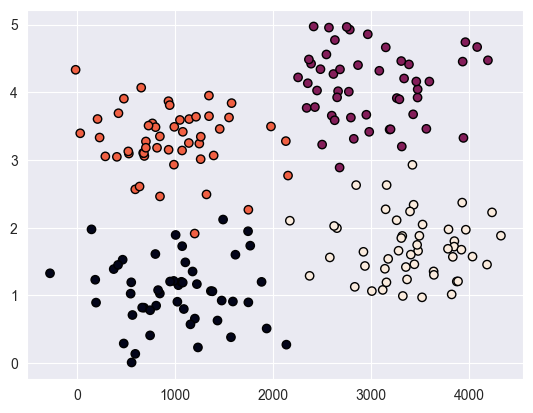

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from seaborn.external.docscrape import header
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler


blob_centers = ([1, 1], [3, 4], [1, 3.3], [3.5, 1.8])
X, y = make_blobs(n_samples=200,
                          centers=blob_centers,
                          cluster_std=0.5,
                          random_state=0)

X[:, 0] *= 1000

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

## Создание и обучение нейроной сети

In [3]:
clf = MLPClassifier(hidden_layer_sizes=(6, ), # 1 входной слой (число нейронов = числу входных атрибутов) - 1 скрытый слой   с 6 нейронами - 1 выходной слой (число классов)
                    random_state=1).fit(X, y)

In [4]:
print("Веса между входным и скрытым слоем:")
print(clf.coefs_[0])
print("\nВеса между скрытым и выходным слоем:")
print(clf.coefs_[1])

Веса между входным и скрытым слоем:
[[-0.09809877  0.33667051 -0.82024119 -0.29720839 -0.56852789 -0.66056109]
 [-0.58903611 -0.31219238 -0.22424296  0.11423652 -0.18324369  0.37321781]]

Веса между скрытым и выходным слоем:
[[-0.51316658 -0.43365467  0.43189995  0.68148414]
 [-0.24370005  0.34328608  0.57835494  0.57889271]
 [-0.59713359 -0.67678056 -0.46609801  0.54011704]
 [-0.5769702  -0.10221922  0.75476969  0.00610289]
 [ 0.34285864 -0.25645017  0.33417991  0.47281254]
 [-0.7006119   0.35515533  0.80295119  0.33880635]]


## Вывод коэффициентов по каждому нейрону

In [5]:
for i in range(len(clf.coefs_)):
    number_neurons_in_layer = clf.coefs_[i].shape[1]
    for j in range(number_neurons_in_layer):
        weights = clf.coefs_[i][:,j]
        print(i, j, weights, end=", ")
        print()
    print()

0 0 [-0.09809877 -0.58903611], 
0 1 [ 0.33667051 -0.31219238], 
0 2 [-0.82024119 -0.22424296], 
0 3 [-0.29720839  0.11423652], 
0 4 [-0.56852789 -0.18324369], 
0 5 [-0.66056109  0.37321781], 

1 0 [-0.51316658 -0.24370005 -0.59713359 -0.5769702   0.34285864 -0.7006119 ], 
1 1 [-0.43365467  0.34328608 -0.67678056 -0.10221922 -0.25645017  0.35515533], 
1 2 [ 0.43189995  0.57835494 -0.46609801  0.75476969  0.33417991  0.80295119], 
1 3 [0.68148414 0.57889271 0.54011704 0.00610289 0.47281254 0.33880635], 



In [6]:
print("Веса смещения для скрытого слоя:")
print(clf.intercepts_[0])
print("\nВеса смещения для выходного слоя:")
print(clf.intercepts_[1])

Веса смещения для скрытого слоя:
[-0.55752645  0.60978582 -0.8640854   0.33258994 -0.18652436  0.05696655]

Веса смещения для выходного слоя:
[-0.29413473  0.49414359 -0.60792984 -0.11888525]


## Метрики качества

In [7]:
metrics.confusion_matrix(y, clf.predict(X))

array([[ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50]])

<Axes: >

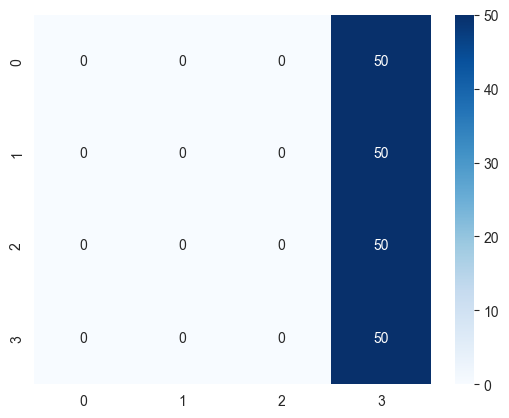

In [8]:
sns.heatmap(metrics.confusion_matrix(y, clf.predict(X)), annot=True, fmt='d', cmap='Blues') # Оси y = true; x = predicted
# TP - FP
# TN - FN

In [9]:
print("Точность: ", metrics.accuracy_score(y, clf.predict(X)))

Точность:  0.25


## Визуализация плохой модели

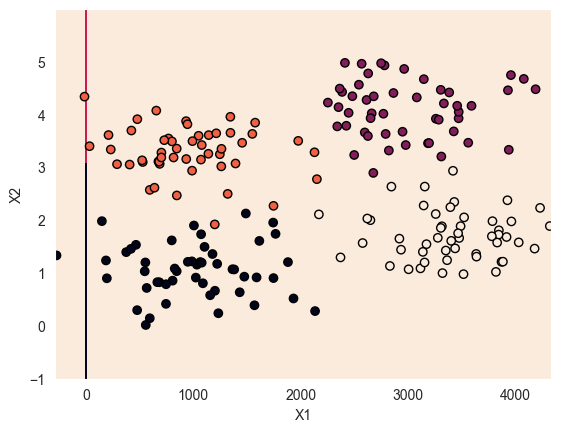

In [10]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

## Исправление ситуации

C:\Users\Bush\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


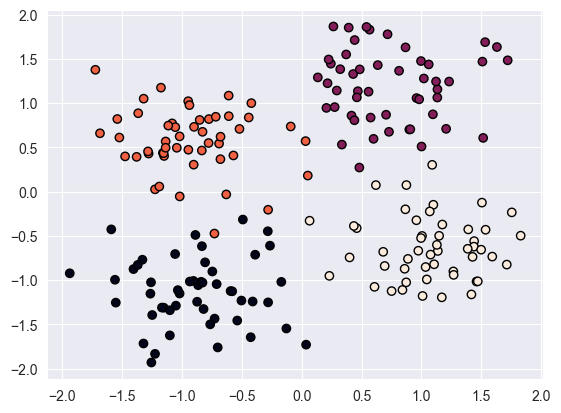

In [11]:
scaler = StandardScaler()

Xs = scaler.fit_transform(X)
plt.scatter(Xs[:, 0], Xs[:, 1], c=y,  edgecolors='black',linewidth=1)

clf_new = MLPClassifier(hidden_layer_sizes=(6, ), # 1 входной слой (число нейронов = числу входных атрибутов) - 1 скрытый слой   с 6 нейронами - 1 выходной слой (число классов)
                    random_state=1).fit(Xs, y)

## Визуализация исправлений и метрики

In [12]:
metrics.confusion_matrix(y, clf_new.predict(Xs))

array([[22,  0, 11, 17],
       [ 0, 38,  0, 12],
       [ 0,  3, 45,  2],
       [ 0,  5,  0, 45]])

<Axes: >

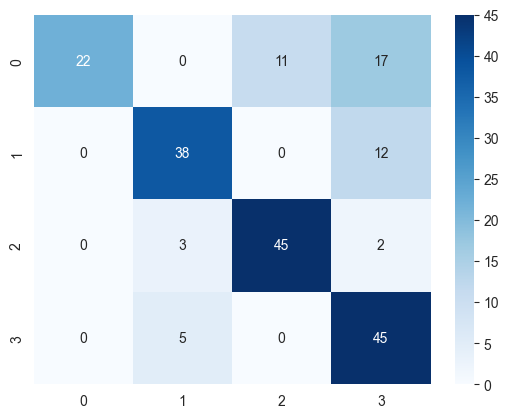

In [13]:
sns.heatmap(metrics.confusion_matrix(y, clf_new.predict(Xs)), annot=True, fmt='d', cmap='Blues') # Оси y = true; x = predicted
# TP - FP
# TN - FN

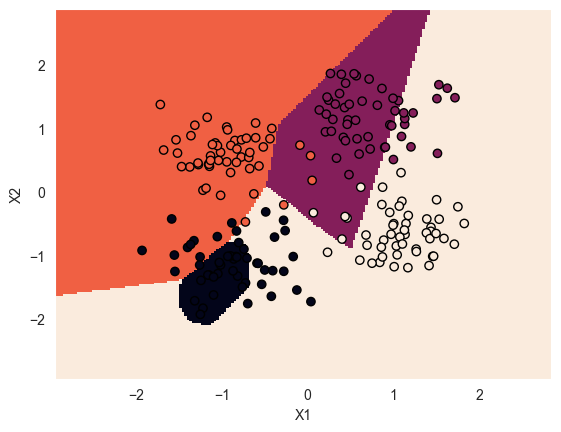

In [14]:
X0 = np.linspace(Xs[:, 0].min()-1,Xs[:, 0].max()+1, Xs.shape[0])
X1 = np.linspace(Xs[:, 1].min()-1,Xs[:, 1].max()+1, Xs.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_new.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(Xs[:, 0], Xs[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [15]:
print("Точность: ", metrics.accuracy_score(y, clf_new.predict(Xs)))

Точность:  0.75


## Улучшение модели добавлением большее итераций

In [16]:
clf = MLPClassifier(hidden_layer_sizes=(6,), max_iter=10_000, verbose=True).fit(Xs, y)

Iteration 1, loss = 1.53442640
Iteration 2, loss = 1.53054233
Iteration 3, loss = 1.52667211
Iteration 4, loss = 1.52281602
Iteration 5, loss = 1.51897482
Iteration 6, loss = 1.51515102
Iteration 7, loss = 1.51134117
Iteration 8, loss = 1.50754639
Iteration 9, loss = 1.50376688
Iteration 10, loss = 1.50000284
Iteration 11, loss = 1.49625553
Iteration 12, loss = 1.49252486
Iteration 13, loss = 1.48881332
Iteration 14, loss = 1.48512245
Iteration 15, loss = 1.48145195
Iteration 16, loss = 1.47780044
Iteration 17, loss = 1.47416670
Iteration 18, loss = 1.47054959
Iteration 19, loss = 1.46695149
Iteration 20, loss = 1.46337350
Iteration 21, loss = 1.45981060
Iteration 22, loss = 1.45626244
Iteration 23, loss = 1.45272873
Iteration 24, loss = 1.44920916
Iteration 25, loss = 1.44570348
Iteration 26, loss = 1.44221143
Iteration 27, loss = 1.43873299
Iteration 28, loss = 1.43527524
Iteration 29, loss = 1.43183090
Iteration 30, loss = 1.42839966
Iteration 31, loss = 1.42498133
Iteration 32, los

In [17]:
metrics.confusion_matrix(y, clf.predict(Xs))

array([[50,  0,  0,  0],
       [ 0, 50,  0,  0],
       [ 2,  0, 48,  0],
       [ 1,  0,  0, 49]])

<Axes: >

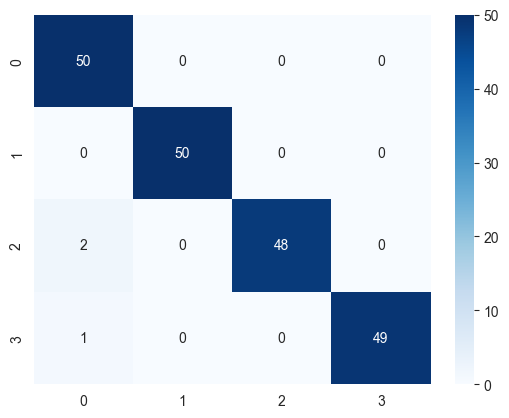

In [18]:
sns.heatmap(metrics.confusion_matrix(y, clf.predict(Xs)), annot=True, fmt='d', cmap='Blues') # Оси y = true; x = predicted
# TP - FP
# TN - FN

In [19]:
print("Точность: ", metrics.accuracy_score(y, clf.predict(Xs)))

Точность:  0.985


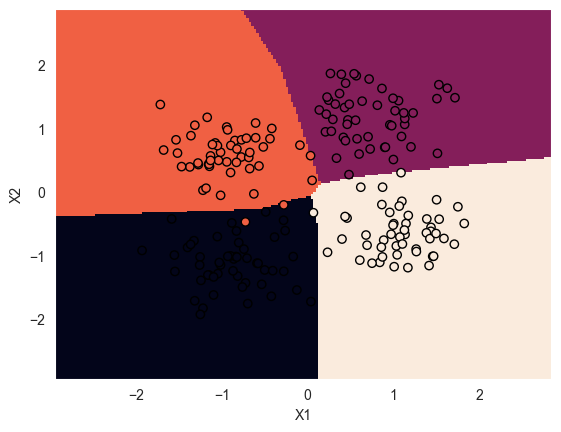

In [20]:
X0 = np.linspace(Xs[:, 0].min()-1,Xs[:, 0].max()+1, Xs.shape[0])
X1 = np.linspace(Xs[:, 1].min()-1,Xs[:, 1].max()+1, Xs.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(Xs[:, 0], Xs[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

## Глубокая нейронная сеть добавлением скрытых слоев

In [21]:
clf_deep = MLPClassifier(hidden_layer_sizes=(6, 6, 6), max_iter=10_000).fit(Xs, y)

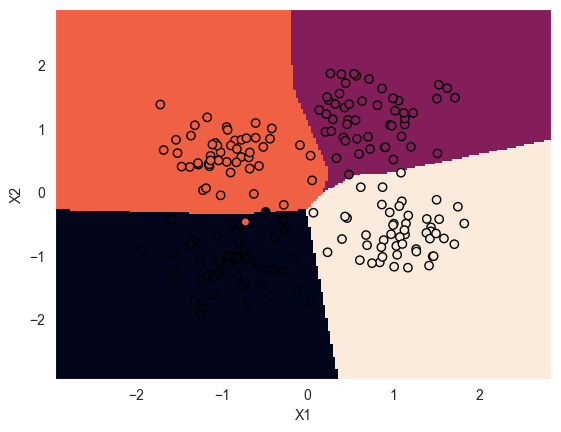

In [22]:
X0 = np.linspace(Xs[:, 0].min()-1,Xs[:, 0].max()+1, Xs.shape[0])
X1 = np.linspace(Xs[:, 1].min()-1,Xs[:, 1].max()+1, Xs.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_deep.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(Xs[:, 0], Xs[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [23]:
metrics.confusion_matrix(y, clf_deep.predict(Xs))

array([[49,  0,  1,  0],
       [ 0, 50,  0,  0],
       [ 1,  0, 49,  0],
       [ 0,  0,  0, 50]])

<Axes: >

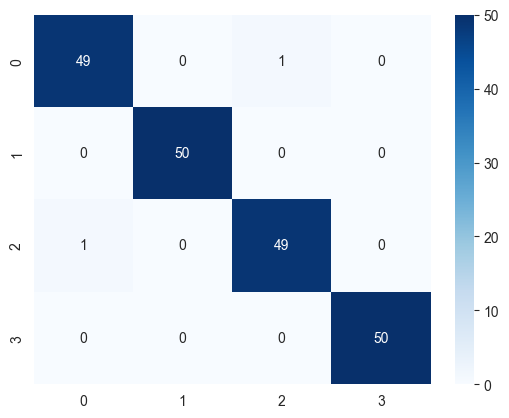

In [24]:
sns.heatmap(metrics.confusion_matrix(y, clf_deep.predict(Xs)), annot=True, fmt='d', cmap='Blues') # Оси y = true; x = predicted
# TP - FP
# TN - FN

In [25]:
print("Точность: ", metrics.accuracy_score(y, clf_deep.predict(Xs)))

Точность:  0.99


# =======================================================================================

# **Самостоятельные задания**

## 1. Создание однослойной модели с 1, 2, 10, 100 нейронами

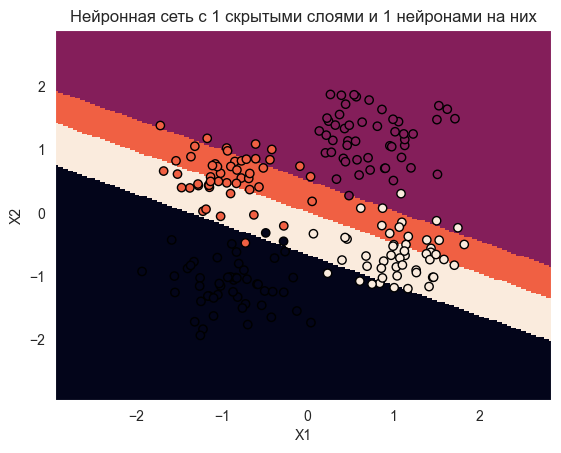



---------------------------

Матрица классификации: 
 [[48  0  0  2]
 [ 0 49  1  0]
 [ 1 10 22 17]
 [ 5  3 16 26]]

---------------------------

Точность:  0.725


======================================================>




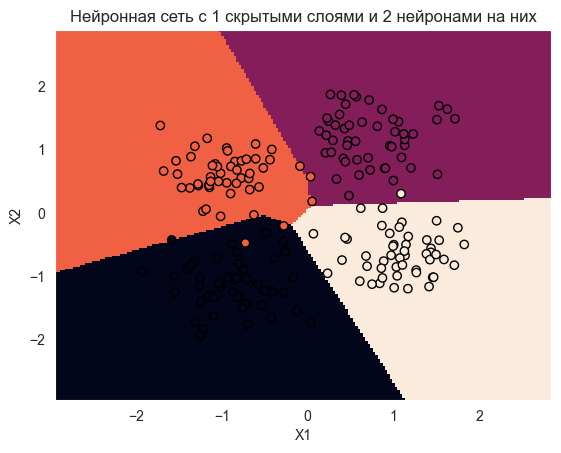



---------------------------

Матрица классификации: 
 [[49  0  1  0]
 [ 0 50  0  0]
 [ 2  3 45  0]
 [ 0  1  0 49]]

---------------------------

Точность:  0.965


======================================================>




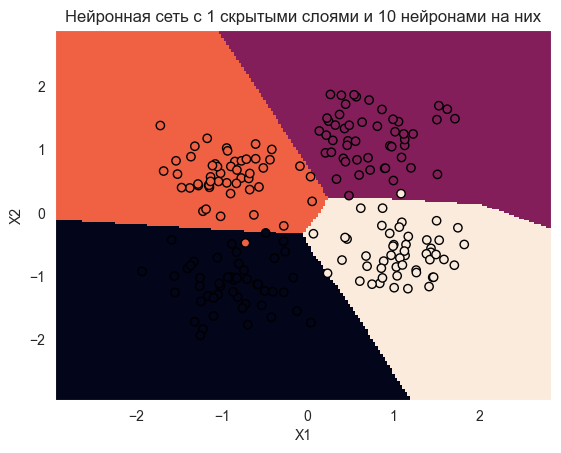



---------------------------

Матрица классификации: 
 [[50  0  0  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 0  1  0 49]]

---------------------------

Точность:  0.99


======================================================>




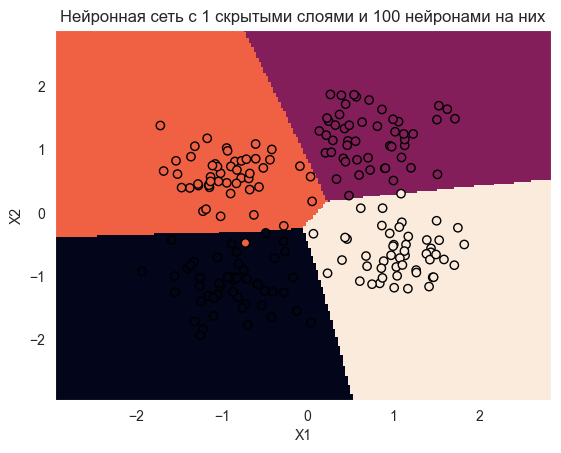



---------------------------

Матрица классификации: 
 [[50  0  0  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 0  0  0 50]]

---------------------------

Точность:  0.995


======================================================>




In [26]:
def print_model(layers, neurons):
    c = (neurons,) * layers
    clf = MLPClassifier(hidden_layer_sizes=c, max_iter=10_000).fit(Xs, y)

    X0 = np.linspace(Xs[:, 0].min()-1,Xs[:, 0].max()+1, Xs.shape[0])
    X1 = np.linspace(Xs[:, 1].min()-1,Xs[:, 1].max()+1, Xs.shape[0])
    X0_grid, X1_grid = np.meshgrid(X0, X1)

    y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
    plt.pcolormesh(X0_grid, X1_grid, y_predict)

    plt.scatter(Xs[:, 0], Xs[:, 1], c=y,  edgecolors='black',linewidth=1)
    plt.xlabel('X1')
    plt.title(f"Нейронная сеть с {layers} скрытыми слоями и {neurons} нейронами на них")
    plt.ylabel('X2')
    plt.show()
    print()
    print()
    print("---------------------------")
    print()
    print("Матрица классификации: \n", metrics.confusion_matrix(y, clf.predict(Xs)))
    print()
    print("---------------------------")
    print()
    print("Точность: ", metrics.accuracy_score(y, clf.predict(Xs)))
    print()
    print()
    print("======================================================>")
    print()
    print()



for i in [1, 2, 10, 100]:
    print_model(1, i)

## 2. Создание модели с разным количеством слоев с одинаковым колчеством  нейронов

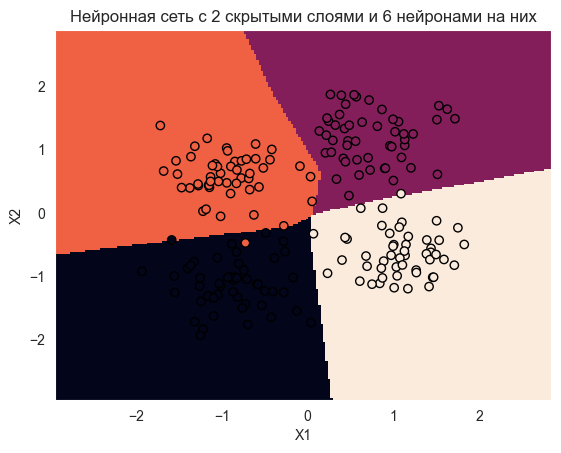



---------------------------

Матрица классификации: 
 [[49  0  1  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 0  1  0 49]]

---------------------------

Точность:  0.985


======================================================>




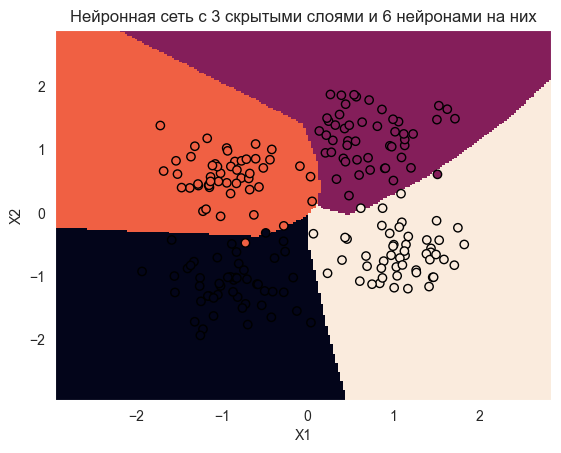



---------------------------

Матрица классификации: 
 [[49  0  1  0]
 [ 0 49  0  1]
 [ 1  0 49  0]
 [ 0  1  0 49]]

---------------------------

Точность:  0.98


======================================================>




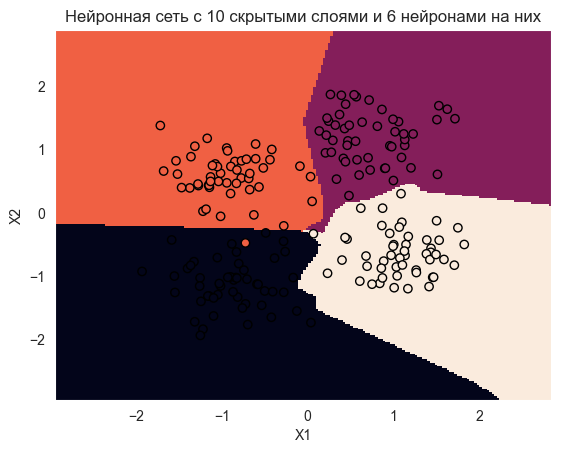



---------------------------

Матрица классификации: 
 [[50  0  0  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 0  0  0 50]]

---------------------------

Точность:  0.995


======================================================>




In [36]:
for i in [2, 3, 10]:
    print_model(i, 6)

## 3. Веса всех нейронов для глубокой модели

In [55]:
deep = MLPClassifier(hidden_layer_sizes=(6, 6, 6), max_iter=10_000).fit(Xs, y) # Глубокая нейросеть с 3 скрытыми слоями по 6 нейронов

print(f"Номер слоя   |   Номер нейрона   |   Его веса")
print("------------------------------------------------------")
for i in range(len(deep.coefs_)):
    number_neurons_in_layer = deep.coefs_[i].shape[1]
    for j in range(number_neurons_in_layer):
        weights = deep.coefs_[i][:,j]
        a = np.round(weights, 2).tolist()
        print(f"{i+1:5}        |      {j:5}        |   {a}")
    print("=======================================================================================================>")
print()
print()
for i in range(len(deep.intercepts_) - 1):
    print(f"Веса смещения {i+1} скрытого слоя: ", deep.intercepts_[i])
print()
print(f"Веса смещения для выходного слоя: ", deep.intercepts_[len(deep.intercepts_) - 1])

Номер слоя   |   Номер нейрона   |   Его веса
------------------------------------------------------
    1        |          0        |   [-0.68, -0.68]
    1        |          1        |   [-0.77, -0.79]
    1        |          2        |   [-0.73, 0.52]
    1        |          3        |   [0.67, 1.12]
    1        |          4        |   [0.56, -0.51]
    1        |          5        |   [-0.44, 1.18]
=======================================================================================================>
    2        |          0        |   [0.19, -0.82, 0.87, -0.75, -0.15, 0.68]
    2        |          1        |   [0.41, 1.24, 0.75, -0.65, -0.54, 0.49]
    2        |          2        |   [0.91, 1.39, 0.08, 0.58, -0.59, -0.13]
    2        |          3        |   [0.5, 0.22, 0.45, -0.2, 1.18, -0.89]
    2        |          4        |   [-0.31, 0.11, -0.75, 1.31, -0.21, 0.51]
    2        |          5        |   [-1.06, 0.03, -0.55, 1.01, 0.25, 0.28]
===============================

## 4. Модель с большим количеством нейронов и слоев

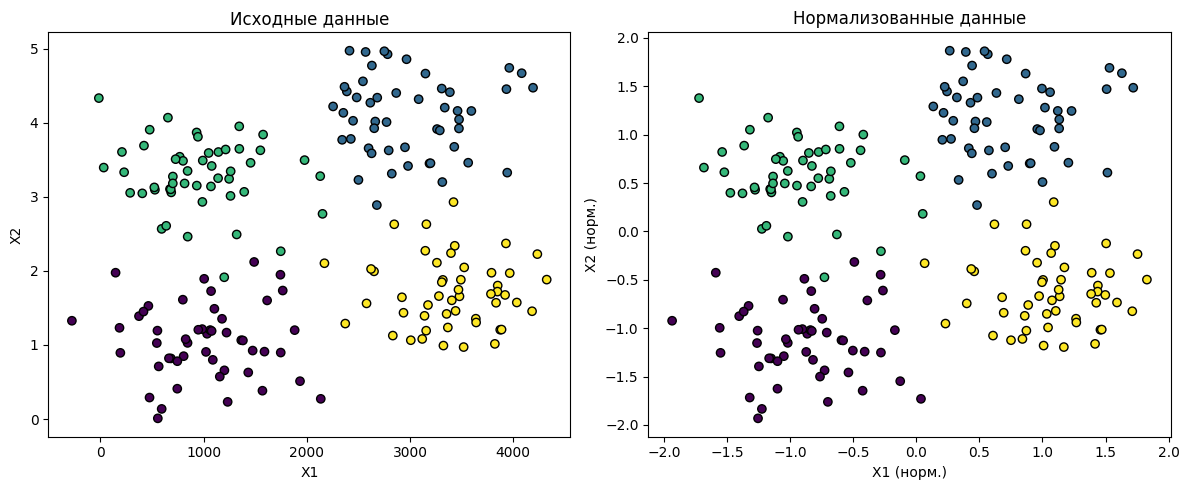

Время обучения простой модели: 0.1047 секунд


C:\Users\Bush\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


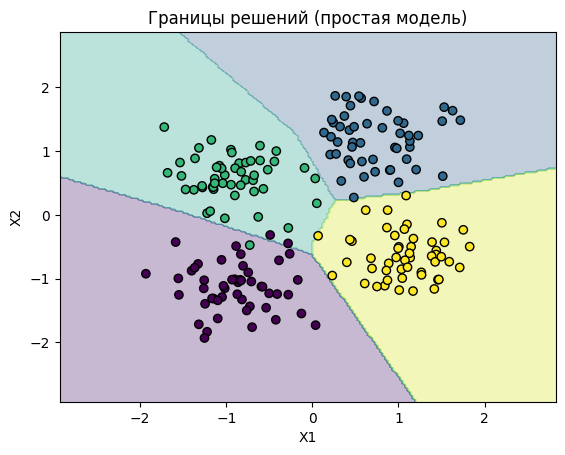

Матрица ошибок простой модели:
[[48  0  2  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 0  0  0 50]]
Iteration 1, loss = 1.48759713
Iteration 2, loss = 1.45908645
Iteration 3, loss = 1.43180218
Iteration 4, loss = 1.40596852
Iteration 5, loss = 1.38102601
Iteration 6, loss = 1.35681812
Iteration 7, loss = 1.33406060
Iteration 8, loss = 1.31208527
Iteration 9, loss = 1.29070706
Iteration 10, loss = 1.26971542
Iteration 11, loss = 1.24991374
Iteration 12, loss = 1.23048956
Iteration 13, loss = 1.21137014
Iteration 14, loss = 1.19296381
Iteration 15, loss = 1.17512823
Iteration 16, loss = 1.15709685
Iteration 17, loss = 1.13890385
Iteration 18, loss = 1.12054444
Iteration 19, loss = 1.10198952
Iteration 20, loss = 1.08325036
Iteration 21, loss = 1.06425917
Iteration 22, loss = 1.04498003
Iteration 23, loss = 1.02540306
Iteration 24, loss = 1.00552255
Iteration 25, loss = 0.98536534
Iteration 26, loss = 0.96496793
Iteration 27, loss = 0.94428016
Iteration 28, loss = 0.92334301
Iteration 29, loss = 

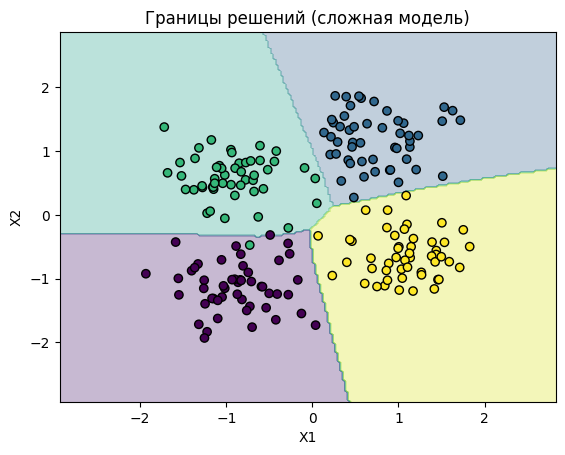

Матрица ошибок сложной модели:
[[49  0  1  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 0  0  0 50]]

Сравнение времени обучения:
Простая модель: 0.1047 сек
Сложная модель: 0.1259 сек


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
import time

# Шаг 1: Генерация данных
blob_centers = ([1, 1], [3, 4], [1, 3.3], [3.5, 1.8])
X, y = make_blobs(n_samples=200, centers=blob_centers, cluster_std=0.5, random_state=0)

# Увеличим первый признак, чтобы было видно разницу
X[:, 0] *= 1000

# Визуализация исходных данных
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black', linewidth=1)
plt.title("Исходные данные")
plt.xlabel("X1")
plt.ylabel("X2")

# Шаг 2: Масштабируем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Визуализация нормализованных данных
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.title("Нормализованные данные")
plt.xlabel("X1 (норм.)")
plt.ylabel("X2 (норм.)")
plt.tight_layout()
plt.show()

# Функция для построения границ принятия решений
def plot_decision_boundary(clf, X, y, title):
    X0 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
    X1 = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
    X0_grid, X1_grid = np.meshgrid(X0, X1)

    y_pred = clf.predict(np.c_[X0_grid.ravel(), X1_grid.ravel()]).reshape(X0_grid.shape)
    plt.contourf(X0_grid, X1_grid, y_pred, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black', linewidth=1)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title(title)

# Шаг 3: Обучение простой модели перцептрона (один слой, 6 нейронов)
clf_simple = MLPClassifier(hidden_layer_sizes=(6,), max_iter=1000, random_state=42)
start_time = time.time()
clf_simple.fit(X_scaled, y)
time_simple = time.time() - start_time

print(f"Время обучения простой модели: {time_simple:.4f} секунд")

# Визуализация границы решений простой модели
plt.figure()
plot_decision_boundary(clf_simple, X_scaled, y, "Границы решений (простая модель)")
plt.show()

# Картинка матрицы ошибок
y_pred_simple = clf_simple.predict(X_scaled)
cm_simple = confusion_matrix(y, y_pred_simple)
print("Матрица ошибок простой модели:")
print(cm_simple)

# Шаг 4: Обучение более сложной модели с большим числом нейронов и слоёв
clf_deep = MLPClassifier(hidden_layer_sizes=(100, 50, 25), max_iter=10000, verbose=True, random_state=42)

start_time = time.time()
clf_deep.fit(X_scaled, y)
time_deep = time.time() - start_time
print()
print(f"Время обучения сложной модели: {time_deep:.4f} секунд")
print()
# Визуализация границ решений более сложной модели
plt.figure()
plot_decision_boundary(clf_deep, X_scaled, y, "Границы решений (сложная модель)")
plt.show()

# Матрица ошибок для сложной модели
y_pred_deep = clf_deep.predict(X_scaled)
cm_deep = confusion_matrix(y, y_pred_deep)
print("Матрица ошибок сложной модели:")
print(cm_deep)

# Итоговая таблица сравнения
print("\nСравнение времени обучения:")
print(f"Простая модель: {time_simple:.4f} сек")
print(f"Сложная модель: {time_deep:.4f} сек")


table = [["Время обучения: ", time_simple, time_deep], ["Точность: ", clf_simple.score(X_scaled, y), clf_deep.score(X_scaled, y)], ]
columns = ["Характеристика", 'Простая модель (1 слой, 6 нейронов)', 'Глубокая модель (3 слоя по 100, 50, 25 нейронов)']

In [13]:
pd.DataFrame(table, columns=columns)

,Характеристика,"Простая модель (1 слой, 6 нейронов)","Глубокая модель (3 слоя по 100, 50, 25 нейронов)"
0,Время обучения:,0.104744,0.125899
1,Точность:,0.985000,0.990000


## 5. Модель на реальном датасете

Iteration 1, loss = 1.05938891
Iteration 2, loss = 1.04320692
Iteration 3, loss = 1.02732755
Iteration 4, loss = 1.01162141
Iteration 5, loss = 0.99614477
Iteration 6, loss = 0.98088906
Iteration 7, loss = 0.96580711
Iteration 8, loss = 0.95086153
Iteration 9, loss = 0.93606079
Iteration 10, loss = 0.92139525
Iteration 11, loss = 0.90668920
Iteration 12, loss = 0.89199481
Iteration 13, loss = 0.87721910
Iteration 14, loss = 0.86234307
Iteration 15, loss = 0.84752646
Iteration 16, loss = 0.83260628
Iteration 17, loss = 0.81770307
Iteration 18, loss = 0.80300821
Iteration 19, loss = 0.78832485
Iteration 20, loss = 0.77372900
Iteration 21, loss = 0.75914588
Iteration 22, loss = 0.74475533
Iteration 23, loss = 0.73047268
Iteration 24, loss = 0.71629683
Iteration 25, loss = 0.70220419
Iteration 26, loss = 0.68835447
Iteration 27, loss = 0.67464314
Iteration 28, loss = 0.66114040
Iteration 29, loss = 0.64795715
Iteration 30, loss = 0.63511592
Iteration 31, loss = 0.62269333
Iteration 32, los

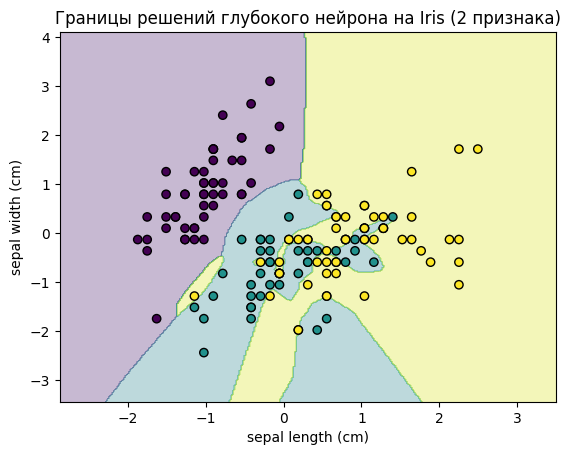

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import time
from sklearn import metrics
import seaborn as sns

# Загружаем датасет Iris
iris = load_iris()
X = iris.data
y = iris.target

# Используем только 2 признака для наглядности
X = X[:, :2]

# Масштабируем признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Создаем глубокую модель
deep_clf = MLPClassifier(
    hidden_layer_sizes=(100, 50, 25),
    max_iter=3000,
    verbose=True,
    random_state=42
)

# Обучение без разделения
start_time = time.time()
deep_clf.fit(X_scaled, y)
train_time = time.time() - start_time

# Выводим время и качество обучения
print(f"\nВремя обучения глубокой модели: {train_time:.2f} секунд")

# Визуализируем границы решений
def plot_decision_boundary(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black', linewidth=1)
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.title(title)
    plt.show()

# Построим границы решений по всему набору
plot_decision_boundary(deep_clf, X_scaled, y, "Границы решений глубокого нейрона на Iris (2 признака)")

<Axes: >

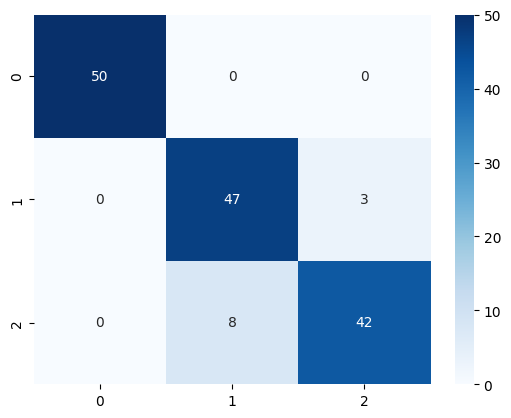

In [20]:
sns.heatmap(metrics.confusion_matrix(y, deep_clf.predict(X_scaled)), annot=True, fmt='d', cmap='Blues') # Оси y = true; x = predicted
# TP - FP
# TN - FN

In [22]:
print("Точность глубокой модели на реальном датасете: ", round(metrics.accuracy_score(y, deep_clf.predict(X_scaled)), 4))

Точность глубокой модели на реальном датасете:  0.9267


## 6. Модель перцептрона на реальном датасете регрессии

Iteration 1, loss = 0.26511665
Iteration 2, loss = 0.23196135
Iteration 3, loss = 0.23023684
Iteration 4, loss = 0.22870254
Iteration 5, loss = 0.22766777
Iteration 6, loss = 0.22849006
Iteration 7, loss = 0.22702212
Iteration 8, loss = 0.22656697
Iteration 9, loss = 0.22639599
Iteration 10, loss = 0.22594137
Iteration 11, loss = 0.22586596
Iteration 12, loss = 0.22656681
Iteration 13, loss = 0.22631978
Iteration 14, loss = 0.22562183
Iteration 15, loss = 0.22606095
Iteration 16, loss = 0.22565253
Iteration 17, loss = 0.22597462
Iteration 18, loss = 0.22589759
Iteration 19, loss = 0.22606409
Iteration 20, loss = 0.22556472
Iteration 21, loss = 0.22568635
Iteration 22, loss = 0.22599120
Iteration 23, loss = 0.22569642
Iteration 24, loss = 0.22601159
Iteration 25, loss = 0.22524088
Iteration 26, loss = 0.22565578
Iteration 27, loss = 0.22553948
Iteration 28, loss = 0.22546147
Iteration 29, loss = 0.22534732
Iteration 30, loss = 0.22538405
Iteration 31, loss = 0.22552226
Iteration 32, los

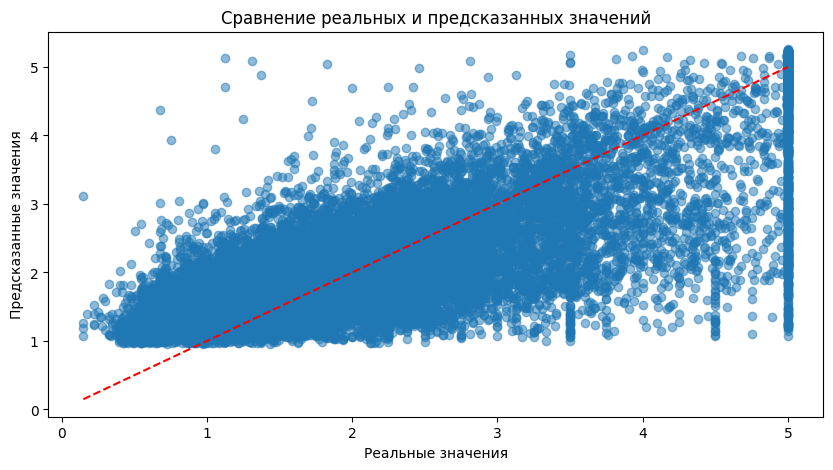


Время обучения (глубокой модели): 1.81 секунд

Коэффициент детерминации R^2: 0.552


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
import time

# Загружаем датасет
california = fetch_california_housing()
X = california.data
y = california.target

# Используем только 2 признака для удобства визуализации
X = X[:, :2]

# Масштабируем признаки и целевую переменную
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()  # делаем вектор

# Создаем глубокую регрессионную модель
deep_regressor = MLPRegressor(
    hidden_layer_sizes=(100, 50, 25),
    max_iter=3000,
    verbose=True,
    random_state=42
)

# Обучаем на всех данных
start_time = time.time()
deep_regressor.fit(X_scaled, y_scaled)
train_time = time.time() - start_time

# Предсказываем
y_pred_scaled = deep_regressor.predict(X_scaled)
# Обратное преобразование для интерпретации результата
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

# Визуализация: сравнение предсказаний и реальных значений
plt.figure(figsize=(10,5))
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные значения")
plt.title("Сравнение реальных и предсказанных значений")
plt.show()

print(f"\nВремя обучения (глубокой модели): {train_time:.2f} секунд")
print()
y_pred_scaled = deep_regressor.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

# Вывод R^2 (коэффициент детерминации)
r2 = r2_score(y, y_pred)
print(f"Коэффициент детерминации R^2: {r2:.3f}")